# 실습 4-3 : SVDD (Support Vector Data Description)

#### **<실습 내용>**

1. SVDD 개념 이해
- One-Class Learning 소개
- SVDD 원리

2. SVDD 모델 학습
- 정상 데이터만으로 Boundary 학습

3. 하이퍼 파라미터 (nu) 변화에 따른 영향
- 과적합 / 과소적합 확인

## 분석 준비

### 주요 라이브러리 호출

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.svm import OneClassSVM

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

### 데이터 불러오기

In [12]:
data = pd.read_csv("dataset/day4-3_data.csv")
print("데이터 크기:", data.shape)
print()
print("클래스 분포:")
print(data["Y"].value_counts())
data.head()

데이터 크기: (100, 3)

클래스 분포:
Y
 1    50
-1    50
Name: count, dtype: int64


,0,1,Y
0,1.040235,-1.873163,1
1,-0.287562,3.278405,1
2,1.100316,3.462647,1
3,2.008401,0.555708,1
4,-0.968919,-2.632187,1


---

## 1) SVDD 개념

> **One-Class 모델**: 정상 데이터만 보고 정상 영역을 학습한 뒤, 그 영역을 벗어나면 이상치로 판단하는 기법
>
> **SVDD**: 정상 데이터를 감싸는 가장 작은 원(구) 모양의 경계를 만드는 방법
> - 중심과 반지름을 학습해서 정상 영역을 정의함
> - $C$ 값이 크면 오분류를 덜 허용해서 경계가 더 타이트해짐 (과적합 위험)
>
> sklearn의 `OneClassSVM`이 이 SVDD와 비슷한 방식의 모델임

### 1-1) 데이터 시각화

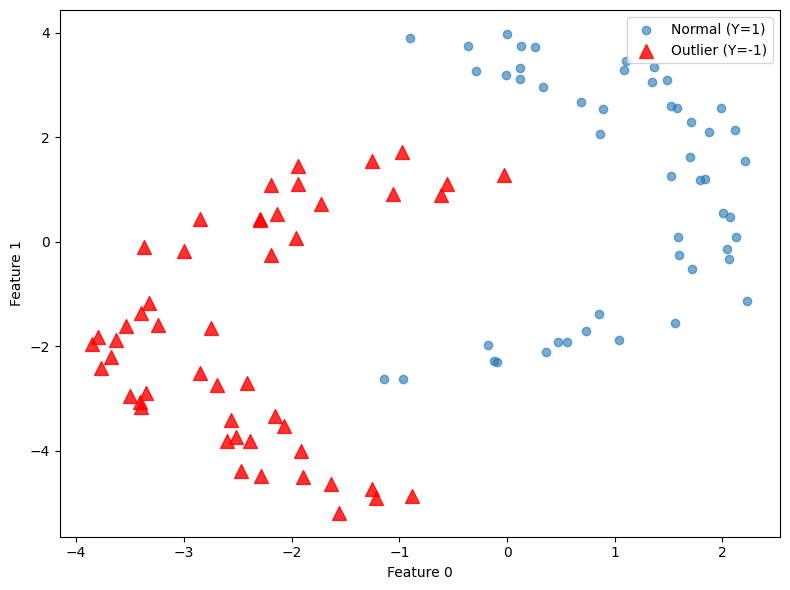

In [13]:
plt.figure(figsize=(8, 6))
normal = data[data["Y"] == 1]  # 정상 데이터만 추출
outlier = data[data["Y"] == -1]  # 이상치 데이터만 추출

plt.scatter(normal["0"], normal["1"], label="Normal (Y=1)", alpha=0.6)  # 정상 데이터 산점도
plt.scatter(outlier["0"], outlier["1"], label="Outlier (Y=-1)", marker="^", s=100, c="red", alpha=0.8)  # 이상치는 빨간 세모로 표시
plt.legend()
plt.xlabel("Feature 0"); plt.ylabel("Feature 1")
plt.tight_layout()
plt.show()

---

## 2) SVDD 모델 학습

> One-Class SVM은 **정상 데이터만으로** 학습함
> - `nu` 파라미터는 이상치 비율의 상한을 설정함 (SVDD의 $C$와 유사한 역할)
> - `kernel="rbf"`를 사용하면 비선형 Boundary를 학습함

### 2-1) 학습/테스트 데이터 분할

In [14]:
X = data[["0", "1"]]
Y = data["Y"]

# 정상 데이터만 추출하여 학습
X_normal = X[Y == 1]
X_outlier = X[Y == -1]

X_train, X_test_normal = train_test_split(X_normal, test_size=0.3, random_state=0)

# 테스트 데이터: 정상 + 이상치
X_test = pd.concat([X_test_normal, X_outlier])
Y_test = pd.Series([1] * len(X_test_normal) + [-1] * len(X_outlier))

print("학습 데이터 (정상만):", X_train.shape)
print("테스트 데이터:", X_test.shape, "(정상:", len(X_test_normal), "이상치:", len(X_outlier),")")

학습 데이터 (정상만): (35, 2)
테스트 데이터: (65, 2) (정상: 15 이상치: 50 )


### 2-2) 모델 학습 및 Boundary 시각화

> `kernel` 옵션 종류
> - `"linear"`: 직선 경계
> - `"poly"`: 다항식 형태의 곡선 경계
> - `"rbf"` (기본값): 가장 유연한 비선형 경계
> - `"sigmoid"`: S자 형태 함수 기반 경계

In [15]:
# One-Class SVM 학습 (nu=0.1, rbf 커널)

# nu : 이상치로 허용할 비율의 상한선
# kernel="rbf" : 곡선 형태로 유연하게 경계를 그림
# gamma="auto" : 경계를 얼마나 세세하게 그릴지 설정 

oc_svm = OneClassSVM(kernel="rbf", gamma="auto", nu=0.1)
oc_svm.fit(X_train)  # 정상 데이터만으로 학습

OneClassSVM(gamma='auto', nu=0.1)

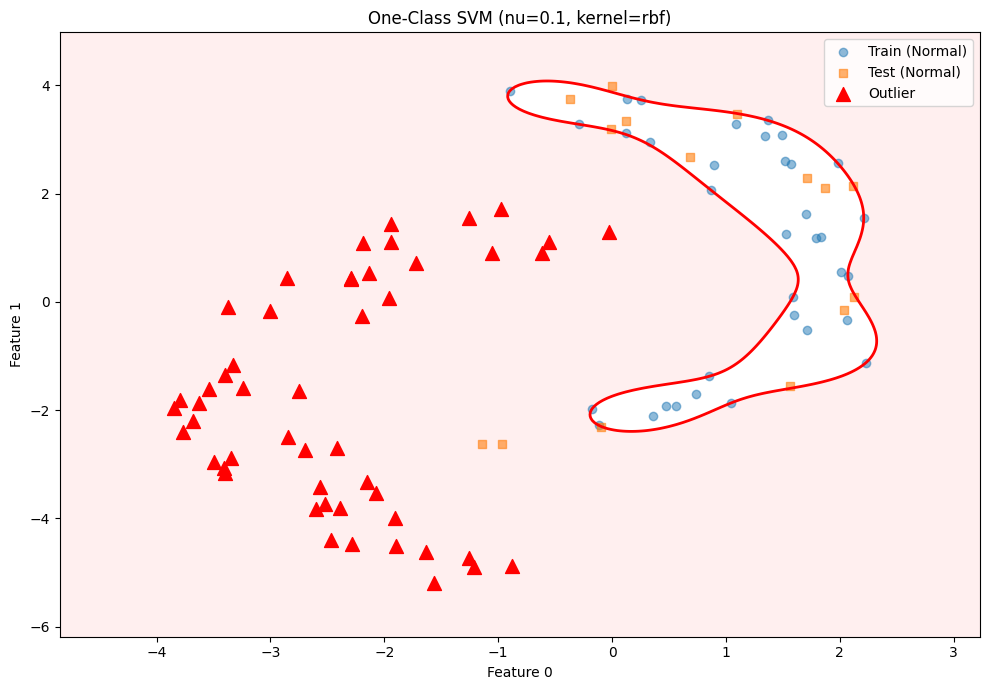

In [16]:
# Decision Boundary 시각화
xx, yy = np.meshgrid(np.linspace(X["0"].min()-1, X["0"].max()+1, 300),  
                     np.linspace(X["1"].min()-1, X["1"].max()+1, 300))
Z = oc_svm.decision_function(pd.DataFrame(np.c_[xx.ravel(), yy.ravel()], columns=["0", "1"])) # 격자의 각 점이 정상 영역에서 얼마나 떨어져있는지 계산
Z = Z.reshape(xx.shape)  # 원래 격자 모양으로 복원

plt.figure(figsize=(10, 7))
plt.contourf(xx, yy, Z, levels=[Z.min(), 0], colors=["#ffcccc"], alpha=0.3)  # 이상치로 판단되는 영역을 옅은 빨강으로 채움
plt.contour(xx, yy, Z, levels=[0], linewidths=2, colors="red")  # 정상/이상치를 가르는 경계선 그리기
plt.scatter(X_train["0"], X_train["1"], label="Train (Normal)", alpha=0.5)  # 학습에 사용한 정상 데이터
plt.scatter(X_test_normal["0"], X_test_normal["1"], label="Test (Normal)", marker="s", alpha=0.6)  # 테스트용 정상 데이터
plt.scatter(X_outlier["0"], X_outlier["1"], label="Outlier", marker="^", s=100, c="red")  # 이상치 데이터
plt.legend()
plt.title("One-Class SVM (nu=0.1, kernel=rbf)")
plt.xlabel("Feature 0"); plt.ylabel("Feature 1")
plt.tight_layout()
plt.show()

### 2-3) 성능 평가

In [ ]:
# 분류 성능 평가 함수
def get_classscore(real, pred, pos_label=1):
    print("Accuracy  : %.3f" % accuracy_score(real, pred))
    print("Precision : %.3f" % precision_score(real, pred, pos_label=pos_label))
    print("Recall    : %.3f" % recall_score(real, pred, pos_label=pos_label))
    print("F1-score  : %.3f" % f1_score(real, pred, pos_label=pos_label))
    print()
    print("혼동행렬:")
    print(confusion_matrix(real, pred))

In [18]:
Y_pred = oc_svm.predict(X_test)
get_classscore(Y_test, Y_pred, pos_label=-1)

Accuracy  : 0.938
Precision : 0.926
Recall    : 1.000
F1-score  : 0.962

혼동행렬:
[[50  0]
 [ 4 11]]


---

## 3) nu 값에 따른 과적합/과소적합 확인

> **`nu` 파라미터**
> - `nu`가 작으면: Boundary가 넓어짐 → 과소적합
> - `nu`가 크면: Boundary가 좁아짐 → 과적합 (정상 데이터도 이상치로 분류되기 쉬움)
> - SVDD의 $C$와 반대 방향으로 작동함 (nu가 클수록 더 많은 정상 데이터가 이상치로 분류됨)

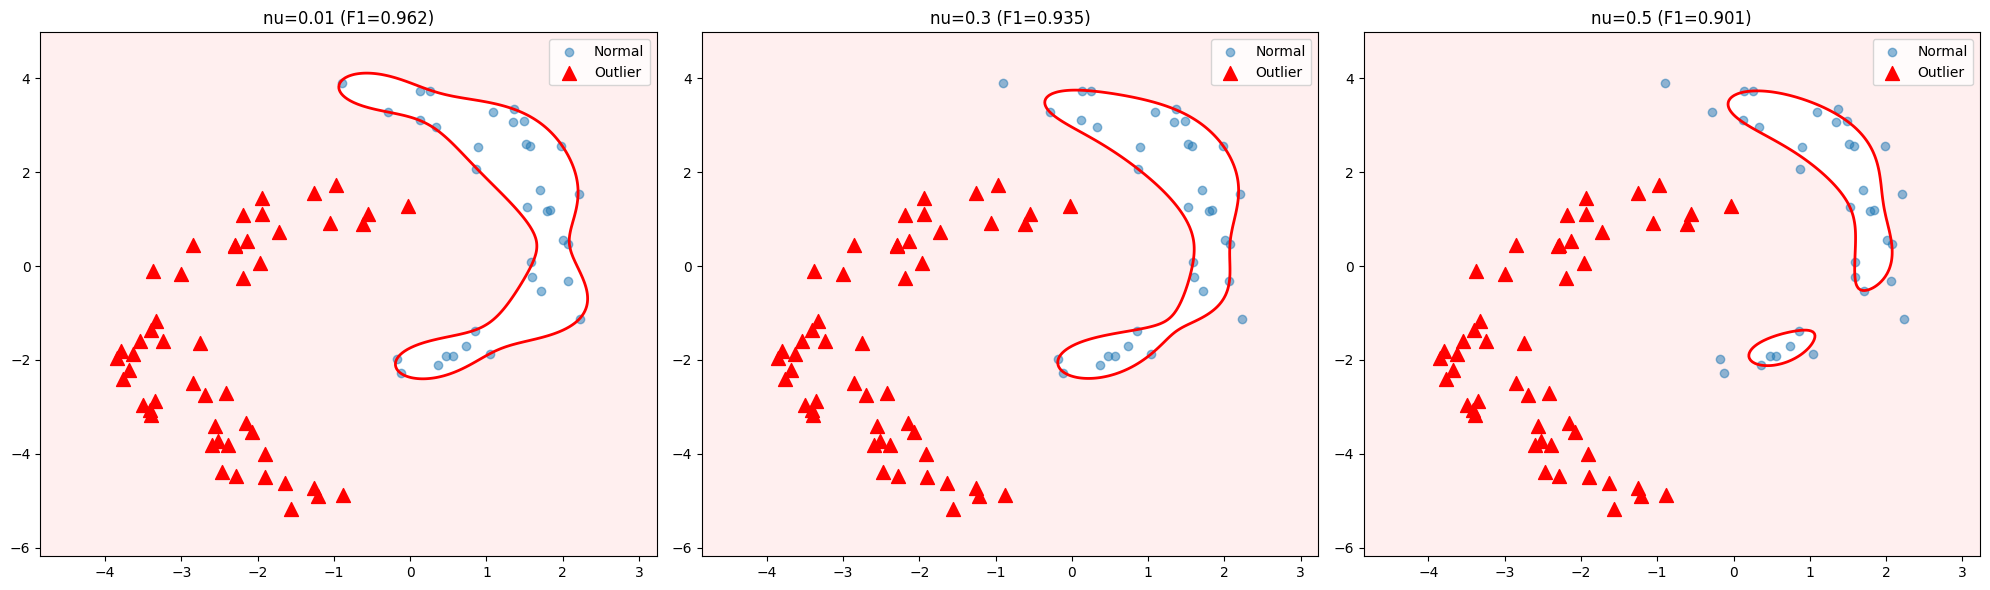

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
nu_values = [0.01, 0.3, 0.5]  

grid_points = pd.DataFrame(np.c_[xx.ravel(), yy.ravel()], columns=["0", "1"]) 

for ax, nu in zip(axes, nu_values):
    model = OneClassSVM(kernel="rbf", gamma="auto", nu=nu)
    model.fit(X_train)

    Z = model.decision_function(grid_points).reshape(xx.shape) 

    ax.contourf(xx, yy, Z, levels=[Z.min(), 0], colors=["#ffcccc"], alpha=0.3)
    ax.contour(xx, yy, Z, levels=[0], linewidths=2, colors="red")
    ax.scatter(X_train["0"], X_train["1"], label="Normal", alpha=0.5)
    ax.scatter(X_outlier["0"], X_outlier["1"], label="Outlier", marker="^", s=100, c="red")

    pred = model.predict(X_test)
    f1 = f1_score(Y_test, pred, pos_label=-1)
    ax.set_title(f"nu={nu} (F1={f1:.3f})")
    ax.legend()

plt.tight_layout()
plt.show()

In [20]:
# nu 값에 따른 성능 변화
results = []
for nu in [0.01, 0.05, 0.1, 0.15, 0.2, 0.3, 0.5]:
    model = OneClassSVM(kernel="rbf", gamma="auto", nu=nu)
    model.fit(X_train)
    pred = model.predict(X_test)
    results.append({
        "nu": nu,
        "F1-score": round(f1_score(Y_test, pred, pos_label=-1), 3),
        "Recall": round(recall_score(Y_test, pred, pos_label=-1), 3),
        "Precision": round(precision_score(Y_test, pred, pos_label=-1), 3)
    })

pd.DataFrame(results)

,nu,F1-score,Recall,Precision
0,0.01,0.962,1.0,0.926
1,0.05,0.962,1.0,0.926
2,0.10,0.962,1.0,0.926
3,0.15,0.962,1.0,0.926
4,0.20,0.962,1.0,0.926
5,0.30,0.935,1.0,0.877
6,0.50,0.901,1.0,0.820


---

## 4) Vibe Coding 실습

**[과제 1]** 지수는 nu 값에 따른 Boundary 변화는 확인했지만, gamma 파라미터도 Boundary 모양에 큰 영향을 준다는 것을 알게 되었습니다. gamma를 "auto"가 아니라 직접 여러 값으로 바꿔보면 어떤 차이가 나는지 궁금합니다. AI와 상의하여 gamma 값을 [0.01, 0.1, 1, 10]으로 바꿔가며 Boundary를 시각화하고 nu와 gamma가 각각 어떤 역할을 하는지 정리해 보세요.

In [ ]:
[프롬프트]

gamma에 따라서도 SVDD의 경계가 어떻게 변하는지 확인하고 싶어.
SVDD 모델 하이퍼파라미터 중 gamma를 여러 값(0.01, 0.1, 1, 10)으로 바꿔가면서

1. Boundary 시각화하는 코드 작성해주고
2. 성능도 출력하는 코드 작성해줘.
3. 내가 1,2에 대한 결과를 주면 nu와 gamma가
어떠한 역할을 하는지 같이 상의해주고 선생님처럼 설명도 해줘.

In [22]:
plt.rcParams["font.family"] = "Malgun Gothic"   # Windows 기본 한글 폰트
plt.rcParams["axes.unicode_minus"] = False       # 마이너스 기호 깨짐 방지

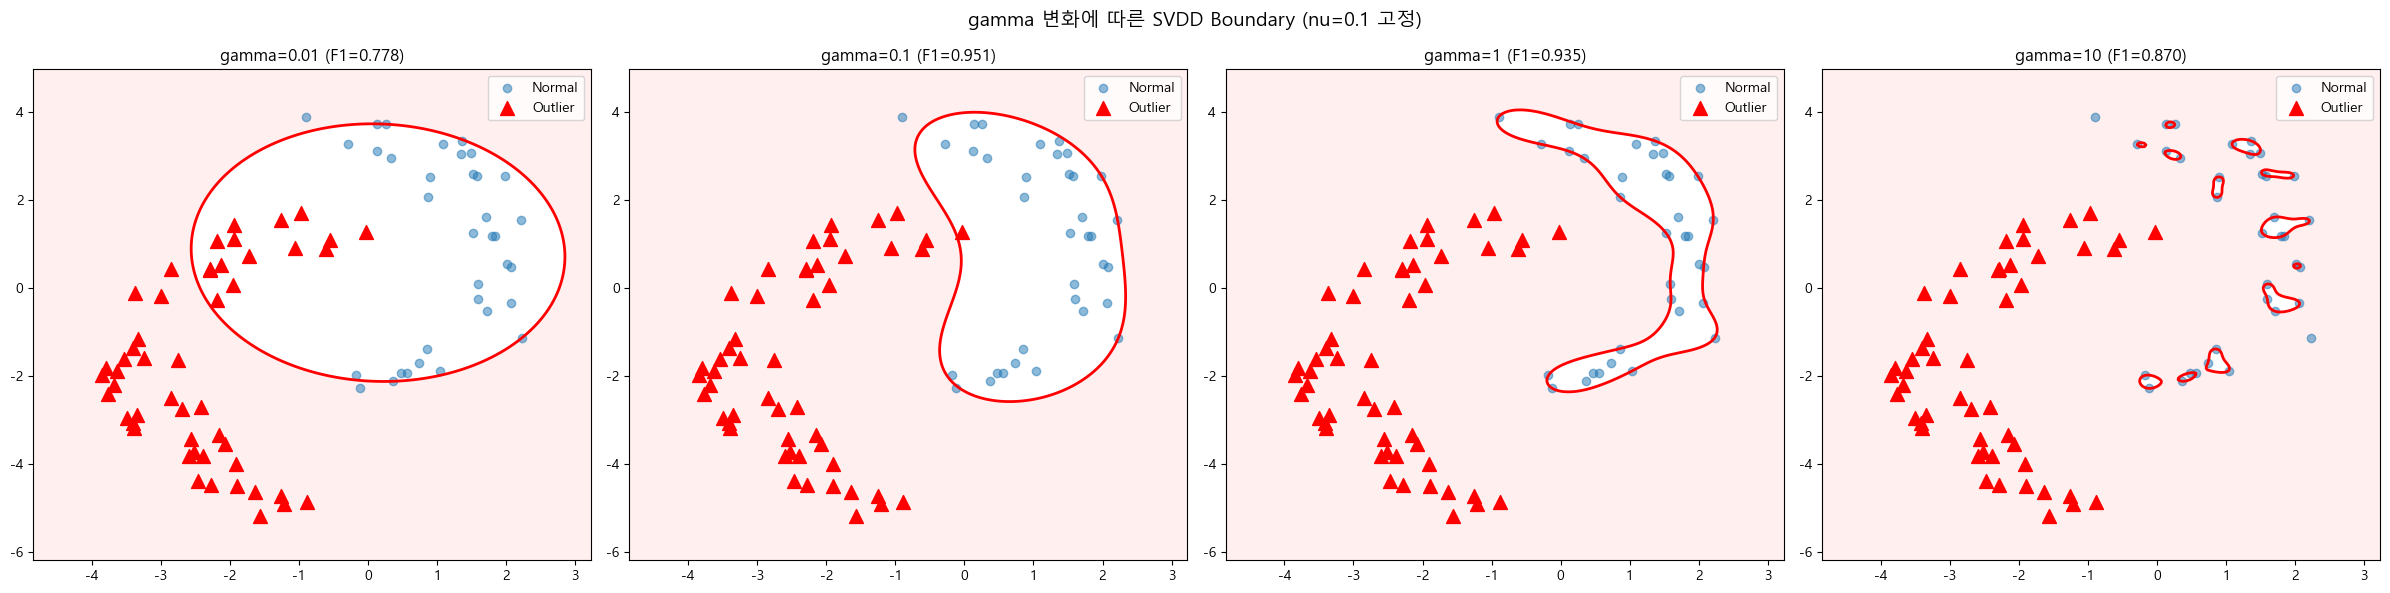

In [23]:
# [1] gamma 값에 따른 Boundary 변화 시각화 (nu=0.1 고정)
gamma_values = [0.01, 0.1, 1, 10]

fig, axes = plt.subplots(1, 4, figsize=(24, 6))
grid_points = pd.DataFrame(np.c_[xx.ravel(), yy.ravel()], columns=["0", "1"])

for ax, gamma in zip(axes, gamma_values):
    model = OneClassSVM(kernel="rbf", gamma=gamma, nu=0.1)
    model.fit(X_train)

    Z = model.decision_function(grid_points).reshape(xx.shape)
    ax.contourf(xx, yy, Z, levels=[Z.min(), 0], colors=["#ffcccc"], alpha=0.3)
    ax.contour(xx, yy, Z, levels=[0], linewidths=2, colors="red")
    ax.scatter(X_train["0"], X_train["1"], label="Normal", alpha=0.5)
    ax.scatter(X_outlier["0"], X_outlier["1"], label="Outlier", marker="^", s=100, c="red")

    pred = model.predict(X_test)
    f1 = f1_score(Y_test, pred, pos_label=-1)
    ax.set_title(f"gamma={gamma} (F1={f1:.3f})")
    ax.legend()

plt.suptitle("gamma 변화에 따른 SVDD Boundary (nu=0.1 고정)", fontsize=14)
plt.tight_layout()
plt.show()

In [24]:
# [2] gamma 값에 따른 성능 변화
results = []
for gamma in [0.001, 0.01, 0.05, 0.1, 0.5, 1, 5, 10]:
    model = OneClassSVM(kernel="rbf", gamma=gamma, nu=0.1)
    model.fit(X_train)
    pred = model.predict(X_test)
    results.append({
        "gamma": gamma,
        "F1-score": round(f1_score(Y_test, pred, pos_label=-1), 3),
        "Recall": round(recall_score(Y_test, pred, pos_label=-1), 3),
        "Precision": round(precision_score(Y_test, pred, pos_label=-1), 3)
    })

pd.DataFrame(results)

,gamma,F1-score,Recall,Precision
0,0.001,0.764,0.68,0.872
1,0.010,0.778,0.70,0.875
2,0.050,0.889,0.88,0.898
3,0.100,0.951,0.98,0.925
4,0.500,0.962,1.00,0.926
5,1.000,0.935,1.00,0.877
6,5.000,0.885,1.00,0.794
7,10.000,0.870,1.00,0.769
